In [7]:
%load_ext autoreload
%autoreload 2
import sys
import pandas
sys.path.append("..")
#import pandas
import numpy as np
import matplotlib.pyplot as plt
import warnings
from numpy import random
from pathlib import Path
warnings.filterwarnings('ignore')
datadir  = '/nfs/scistore26/saricgrp/bmeadowc/Scratch/Collagen/RiccyProject/Revision2/Assembly-AddDenseControl/'
plotsdir = '/nfs/scistore26/saricgrp/bmeadowc/Scratch/Collagen/RiccyProject/Revision2/Assembly-AddDenseControl/Plotting/Plots/'
clrs = ['#a6611a','#dfc27d','#80cdc1','#018571','#f5f5f5']
clrs3 = ['#ffffcc','#c7e9b4','#7fcdbb','#41b6c4','#1d91c0','#225ea8','#0c2c84']

cmap3 = plt.cm.get_cmap('BuPu')
cmap3 = plt.cm.get_cmap('twilight')
cmap3 = plt.cm.get_cmap('PiYG')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


here n 0
got here
got here
got here
got here
got here
got here
MP 0.0001 Time[-1]-Time[0] 3000000
MP 0.0001 Time[-1]-Time[0] 12850600
got here
got here
got here
got here
got here
got here
got here
got here
got here
got here
got here
got here
MP 0.0002 Time[-1]-Time[0] 7311800
got here
got here
got here
got here
got here
got here
MP 0.0004 Time[-1]-Time[0] 5992800
got here
got here
got here
got here
got here
got here
MP 0.0008 Time[-1]-Time[0] 4534800


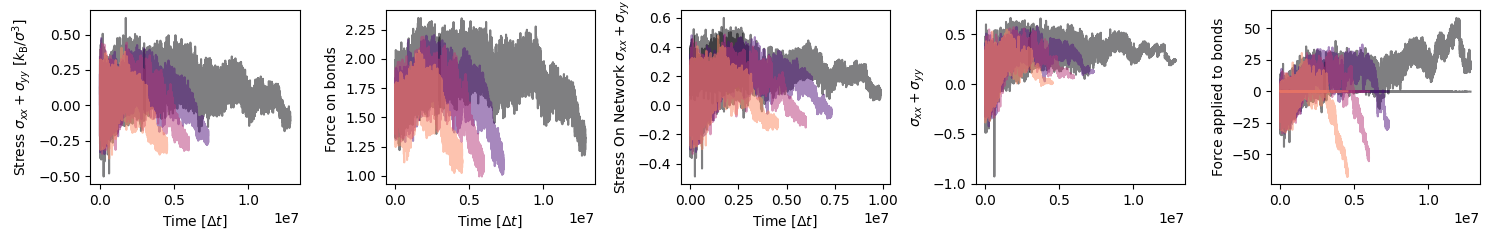

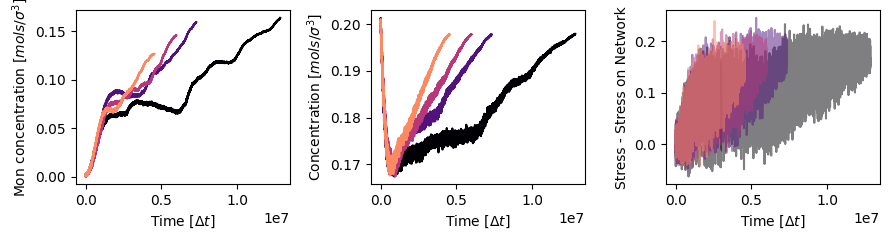

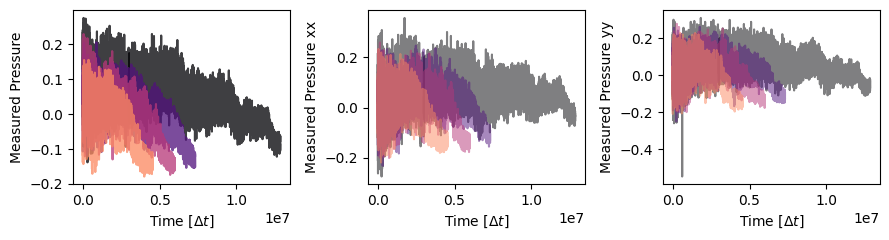

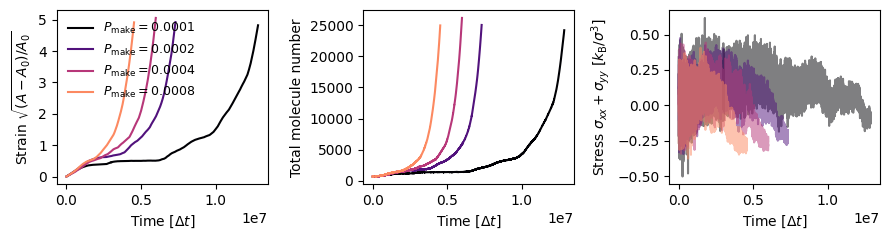

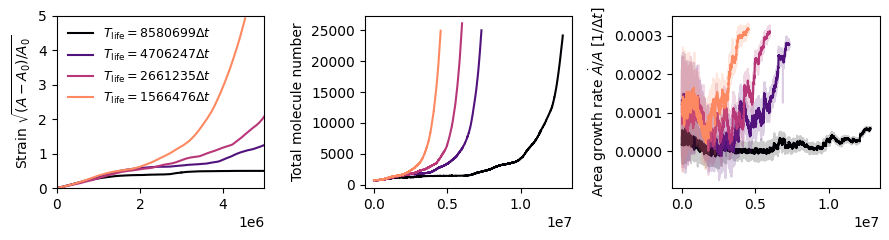

In [2]:
Presses = "-0.1".split()
#Presses = "-0.05".split()
MPs = "0.0001 0.0002 0.0004 0.0008".split() #0.1 0.01 0.001 0.0001 0.00001 0.00001 0.0006 
#MPs = "0.00001 0.0001 0.0002 0.0004 0.0006 0.0008 0.001 0.01 0.1".split() #0.1 0.01 0.001 0.0001 0.00001 0.00001 
# full : [25213.675213675215, 3073.7769388076135, 1683.5016835016831, 949.6750489685841, 692.6816337443578, 556.6938421180851, 484.0271811172293, 171.2822828143642, 85.80995693660945]
NuMons = "5 5 5 5 5 5 5 5".split()
#25213.675213675215,
#[70298597.67644198, 8580699.284143684, 4706247.437784363, 2661235.159674766, 1945350.4212336864, 1566475.77837646, 1364447.8797407264, 499204.0481192192, 258263.1775558024]
lifetimes = np.round([8580699.284143684, 4706247.437784363, 2661235.159674766,1566475.77837646]).astype(int) #45333.333333333336,45333.333333333336,
# Full list : 0.00001, 0.0001 0.0008 0.001 0.01 0.1 ; 45333.333333333336, 3073.7769388076135,1683.5016835016831, 949.6750489685841, 692.6816337443578, 556.6938421180851, 484.0271811172293, 171.2822828143642, 85.80995693660945
fig3,ax3 = plt.subplots(1,5,figsize = (15,2.5))
fig2,ax2 = plt.subplots(1,3,figsize = (9,2.5))
fig4,ax4 = plt.subplots(1,3,figsize = (9,2.5))
fig1,ax1 = plt.subplots(1,3,figsize = (9,2.5))
figNICE,axNICE = plt.subplots(1,3,figsize = (9,2.5))
cmap = plt.get_cmap('magma')
lines = ['-',':','--','-.']
Time_Taking_areas1 = [2.4e6,2.5e6,2.6e6,2.7e6,2.8e6,2.9e6] #0.4e6,0.45e6,0.5e6,0.55e6,0.6e6] #
Time_Taking_areas2 = [3.0e6,3.1e6,3.2e6,3.3e6,3.4e6,3.5e6]
Areas = np.zeros((len(MPs),len(Time_Taking_areas1)+len(Time_Taking_areas2)))
for pp in range(len(Presses)):
    for nn in range(len(MPs)):
        clrs = nn #+1
        lenclr = len(MPs)
        if nn<5 and nn>0:
            foldername = datadir+'run_StretchSm/runTrial_S_kappaD0.01_teq1e7_Frames100_tstep0.01_Nev500_KangNC14.0_MP'+MPs[nn]+'_MP'+MPs[nn]+'_FactMu0.66_MonsPref'+NuMons[nn]+'_MD0.65_BD1.35_MD0.65_BD0.95_Press'+Presses[pp]+'_Pdamp100.0_seed1/'
        else:
            print("here n",nn)
            foldername = datadir+'run_StretchSm/runTrial_S_kappaD0.01_teq3e6_Frames100_tstep0.01_Nev500_KangNC14.0_MP'+MPs[nn]+'_MP'+MPs[nn]+'_FactMu0.66_MonsPref'+NuMons[nn]+'_MD0.65_BD1.35_MD0.65_BD0.95_Press'+Presses[pp]+'_Pdamp100.0_seed1/'
        
        filename = '/thermo.dat'
        thermo = pandas.read_csv(foldername+filename, sep = ' ', header = 'infer')
        press_,stressX_,stressY_,stressZ_,AvBondForce_, BoxVol_  = thermo.press,thermo.stressX,thermo.stressY,thermo.stressZ,thermo.AvBondForce,thermo.BoxVol
        press,stressX,stressY,stressZ,AvBondForce,BoxVol =press_.values,stressX_.values,stressY_.values,stressZ_.values,AvBondForce_.values,BoxVol_.values
        BoxVol = BoxVol_.values
        CurrentConc_, ConcPref_, P_add_, P_remov_ = thermo.CurrentConc,thermo.ConcPref,thermo.P_add,thermo.P_remov
        CurrentConc, ConcPref, P_add, P_remov  = CurrentConc_, ConcPref_, P_add_, P_remov_ 
        NreactNuc_, NreactDeath_ =thermo.NreactNuc,thermo.NreactDeath
        NreactNuc, NreactDeath =NreactNuc_, NreactDeath_ 
        T_den_add_, T_den_remov_, T_id_add_, T_id_remov_ = thermo.T_den_add, thermo.T_den_remov, thermo.T_id_add,  thermo.T_id_remov
        T_den_add, T_den_remov, T_id_add, T_id_remov = T_den_add_, T_den_remov_, T_id_add_, T_id_remov_
        NumTot = thermo.NumTot
        
        
        CurrentMonCount = np.multiply(CurrentConc,BoxVol)
    
        Time_ = thermo.step
        Time = Time_.values
        #print(ConcPref)
        VolInit= 3600
        N=4
        stress = np.convolve(np.divide(np.add(stressX,stressY),BoxVol), np.ones(N)/N, mode='valid')
        
        BondForce = np.convolve(AvBondForce, np.ones(N)/N, mode='valid')

        stressX__N,stressY__N,stressZ__N = thermo.stressX_N,thermo.stressY_N,thermo.stressZ_N
        stressX_N,stressY_N,stressZ_N = stressX_.values,stressY__N.values,stressZ__N.values
        sigma_yy_, sigma_xx_, FtotX_, FtotY_ = thermo.sigma_yy, thermo.sigma_xx, thermo.FtotX, thermo.FtotY
        sigma_yy, sigma_xx, FtotX, FtotY = sigma_yy_, sigma_xx_, FtotX_, FtotY_
        pxx_,pyy_ = thermo.pxx,thermo.pyy
        pxx,pyy = pxx_,pyy_
        stressOnNetwork = np.convolve(np.divide(np.add(stressX_N,stressY_N),BoxVol), np.ones(N)/N, mode='valid')
        Pressure = np.convolve(press, np.ones(N)/N, mode='valid')
        sigma_tot =  np.convolve(np.add(sigma_yy,sigma_yy), np.ones(N)/N, mode='valid')
        F_tot =  np.convolve(np.add(FtotX, FtotY), np.ones(N)/N, mode='valid')

        Pxx =  np.convolve(pxx, np.ones(N)/N, mode='valid')
        Pyy =  np.convolve(pyy, np.ones(N)/N, mode='valid')
        ax3[2].plot(np.add(Time[int(N/2)-1:-int(N/2)],-Time[0]),stressOnNetwork,color = cmap(clrs/lenclr),alpha = 0.5,linestyle = lines[pp])
        AreaInTime = np.divide(BoxVol,12)
        AreaInTimeOG = AreaInTime
        AreaDiff = np.diff(AreaInTime)

        AreaDiffProp = np.divide(AreaDiff,AreaInTime[1:])
        N2=50
        AreaDiffPropAv = np.convolve(AreaDiffProp, np.ones(N2)/N2, mode='valid')
        index_timeArea_init = np.argmin(np.abs((Time - Time[0]) - 0.35e6) )
        index_timeArea_init = np.argmin(np.abs((Time - Time[0]) - 1e6) )
        for ii in range(len(Time_Taking_areas1)):
            index_timeArea = np.argmin(np.abs((Time - Time[0]) - Time_Taking_areas1[ii]) )
            
            Areas[nn,ii] = AreaInTime[index_timeArea]/AreaInTimeOG[0] #/AreaInTime[index_timeArea_init]
        if nn<5:
            for ii in range(len(Time_Taking_areas2)):
                
                index_timeArea = np.argmin(np.abs((Time - Time[0]) - Time_Taking_areas2[ii]))
                print("got here")
                #Areas[nn,ii+len(Time_Taking_areas1)] = AreaInTime[index_timeArea]
                Areas[nn,ii+len(Time_Taking_areas1)] = AreaInTime[index_timeArea]/AreaInTimeOG[0] #/AreaInTimeOG[index_timeArea_init]
            
        axNICE[0].plot(np.add(Time,-Time[0]),np.add(np.divide(np.sqrt(BoxVol),np.sqrt(VolInit)),-1),color = cmap(clrs/lenclr),linestyle = lines[pp],label = r"$T_{\mathrm{life}}=$"+str(lifetimes[nn])+r"$\Delta t$")
        axNICE[1].plot(np.add(Time,-Time[0]),NumTot,color = cmap(clrs/lenclr),linestyle = lines[pp])
        axNICE[2].plot(np.add(Time[1:],-Time[0]),np.divide(AreaDiff,AreaInTime[1:]),color = cmap(clrs/lenclr),linestyle = lines[pp],alpha = 0.2)
        axNICE[2].plot(np.add(Time[int(N2/2):-int(N2/2)],-Time[0]),AreaDiffPropAv,color = cmap(clrs/lenclr),linestyle = lines[pp],alpha = 1)
        #ax1[2].plot(np.add(Time,-Time[0]),np.divide(np.add(stressX,stressY),BoxVol),color = cmap(pp/(len(Presses))),alpha = 0.2)
        ax1[0].plot(np.add(Time,-Time[0]),np.add(np.divide(np.sqrt(BoxVol),np.sqrt(VolInit)),-1),color = cmap(clrs/lenclr),linestyle = lines[pp],label = r"$P_{\mathrm{make}}=$"+MPs[nn])
        ax1[1].plot(np.add(Time,-Time[0]),NumTot,color = cmap(clrs/lenclr),linestyle = lines[pp])
        ax1[2].plot(np.add(Time[int(N/2)-1:-int(N/2)],-Time[0]),stress,color = cmap(clrs/lenclr),alpha = 0.5,linestyle = lines[pp])
        ax3[0].plot(np.add(Time[int(N/2)-1:-int(N/2)],-Time[0]),stress,color = cmap(clrs/lenclr),alpha = 0.5,linestyle = lines[pp])
        ax3[1].plot(np.add(Time[int(N/2)-1:-int(N/2)],-Time[0]),-BondForce,color = cmap(clrs/lenclr),alpha = 0.5,linestyle = lines[pp])
        ax3[3].plot(np.add(Time[int(N/2)-1:-int(N/2)],-Time[0]),-sigma_tot,color = cmap(clrs/lenclr),alpha = 0.5,linestyle = lines[pp])
        ax3[4].plot(np.add(Time[int(N/2)-1:-int(N/2)],-Time[0]),sigma_tot,color = cmap(clrs/lenclr),alpha = 0.5,linestyle = lines[pp])
        ax3[4].plot(np.add(Time[int(N/2)-1:-int(N/2)],-Time[0]),F_tot,color = cmap(clrs/lenclr),alpha = 0.5,linestyle = lines[pp])
        ax4[0].plot(np.add(Time[int(N/2)-1:-int(N/2)],-Time[0]),-Pressure,color = cmap(clrs/lenclr),alpha = 0.5,linestyle = lines[pp])
        ax4[0].plot(np.add(Time[int(N/2)-1:-int(N/2)],-Time[0]),-Pressure,color = cmap(clrs/lenclr),alpha = 0.5,linestyle = lines[pp])
        ax4[1].plot(np.add(Time[int(N/2)-1:-int(N/2)],-Time[0]),-Pyy,color = cmap(clrs/lenclr),alpha = 0.5,linestyle = lines[pp])
        ax4[2].plot(np.add(Time[int(N/2)-1:-int(N/2)],-Time[0]),-Pxx,color = cmap(clrs/lenclr),alpha = 0.5,linestyle = lines[pp])
        print("MP",MPs[nn],"Time[-1]-Time[0]",Time[-1]-Time[0])
        
        
        ax2[1].plot(np.add(Time,-Time[0]),np.divide(NumTot,BoxVol),label = "Current total conc",color = cmap(clrs/lenclr),linestyle = lines[pp])
        ax2[0].plot(np.add(Time,-Time[0]),np.divide(CurrentMonCount,BoxVol),label = 'Current concentration',color = cmap(clrs/lenclr),linestyle = lines[pp])
        ax2[2].plot(np.add(Time[int(N/2)-1:-int(N/2)],-Time[0]),np.subtract(stressOnNetwork,stress),color = cmap(clrs/lenclr),alpha = 0.5,linestyle = lines[pp])

        if nn>4 or nn==0:
            foldername = datadir+'run_StretchSm/runTrialRS_S_kappaD0.01_teq1e7_Frames100_tstep0.01_Nev500_KangNC14.0_MP'+MPs[nn]+'_MP'+MPs[nn]+'_FactMu0.66_MonsPref'+NuMons[nn]+'_MD0.65_BD1.35_MD0.65_BD0.95_Press'+Presses[pp]+'_Pdamp100.0_seed1/'
            filename = '/thermo.dat'
            thermo = pandas.read_csv(foldername+filename, sep = ' ', header = 'infer')
            press_,stressX_,stressY_,stressZ_,AvBondForce_, BoxVol_  = thermo.press,thermo.stressX,thermo.stressY,thermo.stressZ,thermo.AvBondForce,thermo.BoxVol
            press,stressX,stressY,stressZ,AvBondForce,BoxVol =press_.values,stressX_.values,stressY_.values,stressZ_.values,AvBondForce_.values,BoxVol_.values
            BoxVol = BoxVol_.values
            CurrentConc_, ConcPref_, P_add_, P_remov_ = thermo.CurrentConc,thermo.ConcPref,thermo.P_add,thermo.P_remov
            CurrentConc, ConcPref, P_add, P_remov  = CurrentConc_, ConcPref_, P_add_, P_remov_ 
            NreactNuc_, NreactDeath_ =thermo.NreactNuc,thermo.NreactDeath
            NreactNuc, NreactDeath =NreactNuc_, NreactDeath_ 
            T_den_add_, T_den_remov_, T_id_add_, T_id_remov_ = thermo.T_den_add, thermo.T_den_remov, thermo.T_id_add,  thermo.T_id_remov
            T_den_add, T_den_remov, T_id_add, T_id_remov = T_den_add_, T_den_remov_, T_id_add_, T_id_remov_
            NumTot = thermo.NumTot
            
            
            CurrentMonCount = np.multiply(CurrentConc,BoxVol)
            TimeOG = Time
            Time_ = thermo.step
            Time = Time_.values
            #Time = np.add(TimeRS,Time[-1])
            #print(ConcPref)
            VolInit= 3600
            N=4
            stress = np.convolve(np.divide(np.add(stressX,stressY),BoxVol), np.ones(N)/N, mode='valid')
            
            BondForce = np.convolve(AvBondForce, np.ones(N)/N, mode='valid')
    
            stressX__N,stressY__N,stressZ__N = thermo.stressX_N,thermo.stressY_N,thermo.stressZ_N
            stressX_N,stressY_N,stressZ_N = stressX_.values,stressY__N.values,stressZ__N.values
            sigma_yy_, sigma_xx_, FtotX_, FtotY_ = thermo.sigma_yy, thermo.sigma_xx, thermo.FtotX, thermo.FtotY
            sigma_yy, sigma_xx, FtotX, FtotY = sigma_yy_, sigma_xx_, FtotX_, FtotY_
            pxx_,pyy_ = thermo.pxx,thermo.pyy
            pxx,pyy = pxx_,pyy_
            stressOnNetwork = np.convolve(np.divide(np.add(stressX_N,stressY_N),BoxVol), np.ones(N)/N, mode='valid')
            Pressure = np.convolve(press, np.ones(N)/N, mode='valid')
            sigma_tot =  np.convolve(np.add(sigma_yy,sigma_yy), np.ones(N)/N, mode='valid')
            F_tot =  np.convolve(np.add(FtotX, FtotY), np.ones(N)/N, mode='valid')
    
            Pxx =  np.convolve(pxx, np.ones(N)/N, mode='valid')
            Pyy =  np.convolve(pyy, np.ones(N)/N, mode='valid')
            ax3[2].plot(np.add(Time[int(N/2)-1:-int(N/2)],-Time[0]),stressOnNetwork,color = cmap(clrs/lenclr),alpha = 0.5,linestyle = lines[pp])
            AreaInTime = np.divide(BoxVol,12)
            AreaDiff = np.diff(AreaInTime)/(1e7/3e6)

            AreaDiffProp = np.divide(AreaDiff,AreaInTime[1:])
            N2=50
            AreaDiffPropAv = np.convolve(AreaDiffProp, np.ones(N2)/N2, mode='valid')
            print("MP",MPs[nn],"Time[-1]-Time[0]",Time[-1]-TimeOG[0])
            
            axNICE[0].plot(np.add(Time,-TimeOG[0]),np.add(np.divide(np.sqrt(BoxVol),np.sqrt(VolInit)),-1),color = cmap(clrs/lenclr),linestyle = lines[pp])
            
            axNICE[1].plot(np.add(Time,-TimeOG[0]),NumTot,color = cmap(clrs/lenclr),linestyle = lines[pp])
            axNICE[2].plot(np.add(Time[1:],-TimeOG[0]),np.divide(AreaDiff,AreaInTime[1:]),color = cmap(clrs/lenclr),linestyle = lines[pp],alpha = 0.2)
            axNICE[2].plot(np.add(Time[int(N2/2):-int(N2/2)],-TimeOG[0]),AreaDiffPropAv,color = cmap(clrs/lenclr),linestyle = lines[pp],alpha = 1)
            
            #index_timeArea_init = np.argmin(np.abs((Time - TimeOG[0]) - 0.35e6) )
            for ii in range(len(Time_Taking_areas2)):
                
                index_timeArea = np.argmin(np.abs((Time - TimeOG[0]) - Time_Taking_areas2[ii]))
                print("got here")
                #Areas[nn,ii+len(Time_Taking_areas1)] = AreaInTime[index_timeArea]
                Areas[nn,ii+len(Time_Taking_areas1)] = AreaInTime[index_timeArea]/AreaInTimeOG[0] #/AreaInTimeOG[index_timeArea_init]
            
            ax1[0].plot(np.add(Time,-TimeOG[0]),np.add(np.divide(np.sqrt(BoxVol),np.sqrt(VolInit)),-1),color = cmap(clrs/lenclr),linestyle = lines[pp])
            ax1[1].plot(np.add(Time,-TimeOG[0]),NumTot,color = cmap(clrs/lenclr),linestyle = lines[pp])
            #ax1[2].plot(np.add(Time,-Time[0]),np.divide(np.add(stressX,stressY),BoxVol),color = cmap(pp/(len(Presses))),alpha = 0.2)
            ax1[2].plot(np.add(Time[int(N/2)-1:-int(N/2)],-TimeOG[0]),stress,color = cmap(clrs/lenclr),alpha = 0.5,linestyle = lines[pp])
            ax3[0].plot(np.add(Time[int(N/2)-1:-int(N/2)],-TimeOG[0]),stress,color = cmap(clrs/lenclr),alpha = 0.5,linestyle = lines[pp])
            ax3[1].plot(np.add(Time[int(N/2)-1:-int(N/2)],-TimeOG[0]),-BondForce,color = cmap(clrs/lenclr),alpha = 0.5,linestyle = lines[pp])
            ax3[3].plot(np.add(Time[int(N/2)-1:-int(N/2)],-TimeOG[0]),-sigma_tot,color = cmap(clrs/lenclr),alpha = 0.5,linestyle = lines[pp])
            ax3[4].plot(np.add(Time[int(N/2)-1:-int(N/2)],-TimeOG[0]),sigma_tot,color = cmap(clrs/lenclr),alpha = 0.5,linestyle = lines[pp])
            ax3[4].plot(np.add(Time[int(N/2)-1:-int(N/2)],-TimeOG[0]),F_tot,color = cmap(clrs/lenclr),alpha = 0.5,linestyle = lines[pp])
            ax4[0].plot(np.add(Time[int(N/2)-1:-int(N/2)],-TimeOG[0]),-Pressure,color = cmap(clrs/lenclr),alpha = 0.5,linestyle = lines[pp])
            ax4[0].plot(np.add(Time[int(N/2)-1:-int(N/2)],-TimeOG[0]),-Pressure,color = cmap(clrs/lenclr),alpha = 0.5,linestyle = lines[pp])
            ax4[1].plot(np.add(Time[int(N/2)-1:-int(N/2)],-TimeOG[0]),-Pyy,color = cmap(clrs/lenclr),alpha = 0.5,linestyle = lines[pp])
            ax4[2].plot(np.add(Time[int(N/2)-1:-int(N/2)],-TimeOG[0]),-Pxx,color = cmap(clrs/lenclr),alpha = 0.5,linestyle = lines[pp])
            
            ax2[1].plot(np.add(Time,-TimeOG[0]),np.divide(NumTot,BoxVol),label = "Current total conc",color = cmap(clrs/lenclr),linestyle = lines[pp])
            ax2[0].plot(np.add(Time,-TimeOG[0]),np.divide(CurrentMonCount,BoxVol),label = 'Current concentration',color = cmap(clrs/lenclr),linestyle = lines[pp])
            ax2[2].plot(np.add(Time[int(N/2)-1:-int(N/2)],-TimeOG[0]),np.subtract(stressOnNetwork,stress),color = cmap(clrs/lenclr),alpha = 0.5,linestyle = lines[pp])
            
        
for i in range(3):
    ax1[i].set_xlabel(r'Time [$\Delta t$]')
    ax2[i].set_xlabel(r'Time [$\Delta t$]')
    ax3[i].set_xlabel(r'Time [$\Delta t$]')
    ax4[i].set_xlabel(r'Time [$\Delta t$]')
    # ax1[i].set_xlim([0,30000])
    # ax2[i].set_xlim([0,30000])
    # ax3[i].set_xlim([0,30000])
axNICE[0].set_xlim([0,5e6])
axNICE[0].set_ylim([0,5])
    
ax1[0].legend(frameon=False,fontsize =9)
axNICE[0].legend(frameon=False,fontsize =9)
# ax1[0].set_ylim([0,0.006])
# ax1[1].set_ylim([3105,3130])
# ax1[2].set_ylim([-0.15,0.05])
# ax3[0].set_ylim([-0.15,0.05])
# ax3[1].set_ylim([1.35,1.55])
# ax3[2].set_ylim([-0.07,0.02])
ax1[0].set_ylabel(r"Strain $\sqrt{(A-A_{0})/A_{0}}$")
ax1[1].set_ylabel(r"Total molecule number")

axNICE[0].set_ylabel(r"Strain $\sqrt{(A-A_{0})/A_{0}}$")
axNICE[1].set_ylabel(r"Total molecule number")
axNICE[2].set_ylabel(r"Area growth rate $\dot{A}/A~[1/\Delta t]$")
ax2[0].set_ylabel(r"Mon concentration [$mols/\sigma^3$]")
ax2[1].set_ylabel(r"Concentration [$mols/\sigma^3$]")
ax2[2].set_ylabel(r"Stress - Stress on Network")

ax1[2].set_ylabel(r"Stress $\sigma_{xx}+\sigma_{yy}$ [$k_{\mathrm{B}}/\sigma^3$]")

ax3[0].set_ylabel(r"Stress $\sigma_{xx}+\sigma_{yy}$ [$k_{\mathrm{B}}/\sigma^3$]")
ax3[2].set_ylabel(r"Stress On Network $\sigma_{xx}+\sigma_{yy}$")
ax3[3].set_ylabel(r"$\sigma_{xx}+\sigma_{yy}$")
ax3[4].set_ylabel(r"Force applied to bonds")
ax3[1].set_ylabel(r"Force on bonds ")
ax4[0].set_ylabel(r"Measured Pressure")
ax4[1].set_ylabel(r"Measured Pressure xx")
ax4[2].set_ylabel(r"Measured Pressure yy")

fig1.tight_layout()
fig2.tight_layout()
fig3.tight_layout()
fig4.tight_layout()
figNICE.tight_layout()

NameError: name 'df_times' is not defined

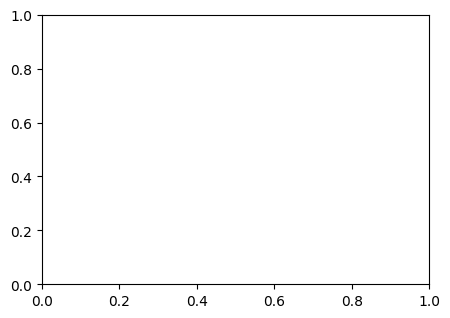

In [3]:
cmap = plt.get_cmap('magma')
fig,ax = plt.subplots(figsize = (5.,3.5))
#Time_Taking_areas_scaled = np.subtract(Time_Taking_areas1,0.35e6)
#Time_Taking_areas_scaled2 = np.subtract(Time_Taking_areas2,0.35e6)
Time_Taking_areas_scaled = np.subtract(Time_Taking_areas1,1e6)
Time_Taking_areas_scaled2 = np.subtract(Time_Taking_areas2,1e6)


# concatenate lifetimes (t') values
Time_Taking_areas_scaled = np.concatenate([
    np.asarray(Time_Taking_areas1) - 1e6,
    np.asarray(Time_Taking_areas2) - 1e6
])

rows = []

for ii, times in enumerate(Time_Taking_areas_scaled):
    for jj, lt in enumerate(lifetimes):
        rows.append({
            "lifetime": lt,      # t'
            "x": times/lt,         # x-axis value
            "area": Areas[jj, ii],            # y-axis value
            "curve_id": jj                    # optional, for colouring/grouping
        })

df = pandas.DataFrame(rows)

df.to_csv("area_vs_lifetime.csv", index=False)

df_times.to_csv("time_taking_areas.csv", index=False)

for ii in range(len(Time_Taking_areas1)):
    #ax.plot(np.divide(lifetimes,Time_Taking_areas1[ii]),np.divide(Areas[:,ii],VolInit/12),marker='o',color = cmap(ii/6),label = r"$t' = $"+str(np.round(np.divide(Time_Taking_areas1[ii],1e4)).astype(int))+r"$\times10^5\Delta$")
    if ii%2==0:
        ax.plot(np.divide(Time_Taking_areas_scaled[ii],lifetimes,),np.divide(Areas[:,ii],1),marker='o',color = cmap(ii/12),linestyle = '',label = r"$t' = $"+str(np.round(np.divide(Time_Taking_areas_scaled[ii],1e4)).astype(int))+r"$\times10^5\Delta$")
    else:
        ax.plot(np.divide(Time_Taking_areas_scaled[ii],lifetimes),np.divide(Areas[:,ii],1),marker='o',color = cmap(ii/12),linestyle = '')
    
for ii in range(len(Time_Taking_areas2)):
   #ax.plot(np.divide(lifetimes,Time_Taking_areas2[ii]),np.divide(Areas[:,ii+len(Time_Taking_areas1)],VolInit/12),color = cmap((ii+len(Time_Taking_areas1))/6),marker='o',label = r"$t' = $"+str(np.round(np.divide(Time_Taking_areas2[ii],1e5)).astype(int))+r"$\times10^5\Delta$")
    if ii%2==0:
        ax.plot(np.divide(Time_Taking_areas_scaled2[ii],lifetimes),np.divide(Areas[:,ii+len(Time_Taking_areas1)],1),linestyle = '',color = cmap((ii+len(Time_Taking_areas1))/12),marker='o',label = r"$t' = $"+str(np.round(np.divide(Time_Taking_areas_scaled2[ii],1e5)).astype(int))+r"$\times10^5\Delta$")
    else:
        ax.plot(np.divide(Time_Taking_areas_scaled2[ii],lifetimes),np.divide(Areas[:,ii+len(Time_Taking_areas1)],1),linestyle = '',color = cmap((ii+len(Time_Taking_areas1))/12),marker='o')

#ax.set_xscale('log')
#ax.set_yscale('log')
ax.set_xlabel(r"Re-scaled CollIV lifetime, $T_{\mathrm{life}}/t'$",fontsize = 12)
ax.set_ylabel(r"Area change at time t', $A(t')/A_{0}~[\sigma^2]$",fontsize = 12)
#ax.set_xticks([0.0005,0.001,0.0015,0.002])
ax.legend(frameon=False)
fig.tight_layout()
plotname = "RescaledArea.pdf"
fig.savefig(plotsdir+plotname)


cmap = plt.get_cmap('magma')
fig,ax = plt.subplots(figsize = (3.5,2.2))
#Time_Taking_areas_scaled = np.subtract(Time_Taking_areas1,0.35e6)
#Time_Taking_areas_scaled2 = np.subtract(Time_Taking_areas2,0.35e6)
Time_Taking_areas_scaled = np.subtract(Time_Taking_areas1,1e6)
Time_Taking_areas_scaled2 = np.subtract(Time_Taking_areas2,1e6)
for ii in range(len(Time_Taking_areas1)):
    #ax.plot(np.divide(lifetimes,Time_Taking_areas1[ii]),np.divide(Areas[:,ii],VolInit/12),marker='o',color = cmap(ii/6),label = r"$t' = $"+str(np.round(np.divide(Time_Taking_areas1[ii],1e4)).astype(int))+r"$\times10^5\Delta$")
    if ii%2==0:
        ax.plot(np.divide(Time_Taking_areas_scaled[ii],lifetimes),np.divide(Areas[:,ii],1),marker='o',color = cmap(ii/12),linestyle = '',label = r"$t' = $"+str(np.round(np.divide(Time_Taking_areas_scaled[ii],1e4)).astype(int))+r"$\times10^5\Delta$")
    else:
        ax.plot(np.divide(Time_Taking_areas_scaled[ii],lifetimes),np.divide(Areas[:,ii],1),marker='o',color = cmap(ii/12),linestyle = '')
    
for ii in range(len(Time_Taking_areas2)):
   #ax.plot(np.divide(lifetimes,Time_Taking_areas2[ii]),np.divide(Areas[:,ii+len(Time_Taking_areas1)],VolInit/12),color = cmap((ii+len(Time_Taking_areas1))/6),marker='o',label = r"$t' = $"+str(np.round(np.divide(Time_Taking_areas2[ii],1e5)).astype(int))+r"$\times10^5\Delta$")
    if ii%2==0:
        ax.plot(np.divide(Time_Taking_areas_scaled2[ii],lifetimes),np.divide(Areas[:,ii+len(Time_Taking_areas1)],1),linestyle = '',color = cmap((ii+len(Time_Taking_areas1))/12),marker='o',label = r"$t' = $"+str(np.round(np.divide(Time_Taking_areas_scaled2[ii],1e5)).astype(int))+r"$\times10^5\Delta$")
    else:
        ax.plot(np.divide(Time_Taking_areas_scaled2[ii],lifetimes),np.divide(Areas[:,ii+len(Time_Taking_areas1)],1),linestyle = '',color = cmap((ii+len(Time_Taking_areas1))/12),marker='o')

ax.set_xscale('log')
ax.set_yscale('log')
#ax.set_xlabel(r"Re-scaled CollIV lifetime, $T_{\mathrm{life}}/t'$",fontsize = 12)
#ax.set_ylabel(r"Area change at time t', $A(t')/A_{0}~[\sigma^2]$",fontsize = 12)
#ax.set_xticks([0.0005,0.001,0.0015,0.002])
#ax.legend(frameon=False)

here n 0
frame 60
got here
got here
got here
got here
got here
got here
MP 0.0001 Time[-1]-Time[0] 3000000
MP 0.0001 Time[-1]-Time[0] 12850600
got here
got here
got here
got here
got here
got here
frame 200
got here
got here
got here
got here
got here
got here
MP 0.0001 Time[-1]-Time[0] 10000000
frame 200
got here
got here
got here
got here
got here
got here
MP 0.0001 Time[-1]-Time[0] 10000000
MP 0 MaxLen 50001
frame 200
got here
got here
got here
got here
got here
got here
MP 0.0002 Time[-1]-Time[0] 7311800
frame 200
got here
got here
got here
got here
got here
got here
MP 0.0002 Time[-1]-Time[0] 9009800
frame 200
got here
got here
got here
got here
got here
got here
MP 0.0002 Time[-1]-Time[0] 8947800
MP 1 MaxLen 36560
frame 200
got here
got here
got here
got here
got here
got here
MP 0.0004 Time[-1]-Time[0] 5992800
frame 200
got here
got here
got here
got here
got here
got here
MP 0.0004 Time[-1]-Time[0] 5550000
frame 200
got here
got here
got here
got here
got here
got here
MP 0.000

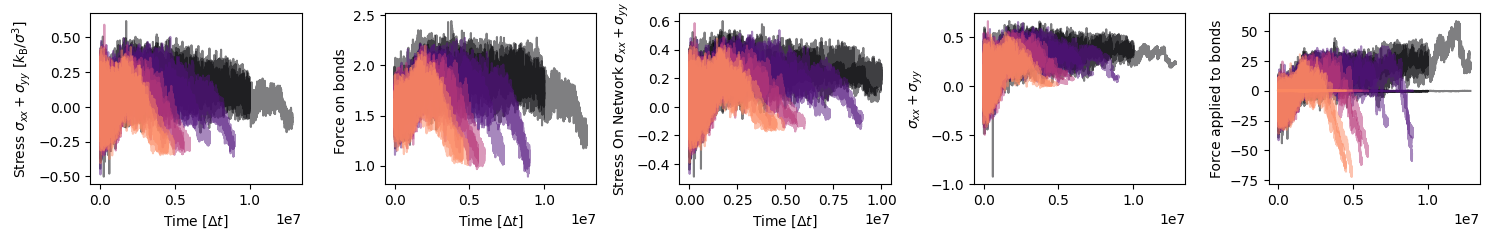

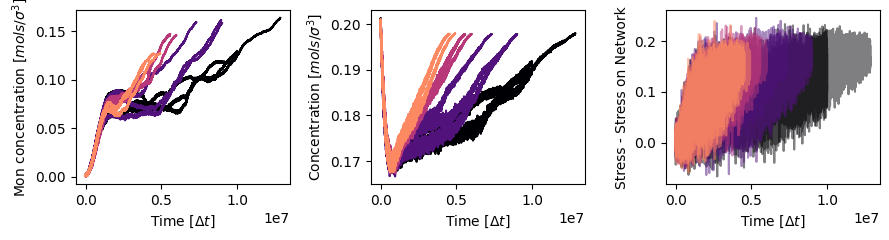

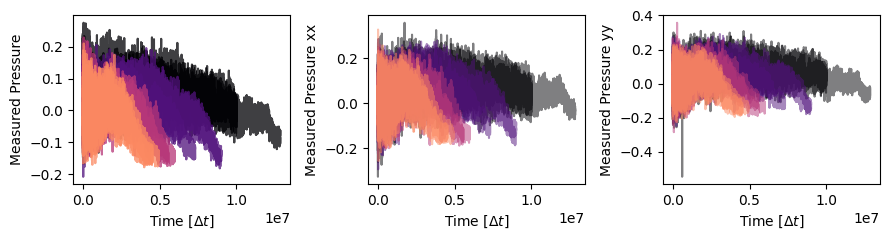

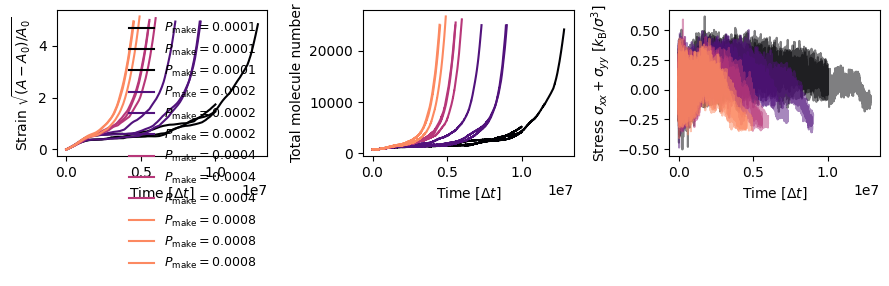

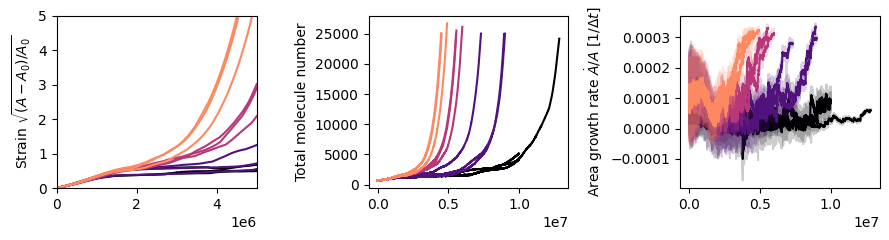

In [4]:
Presses = "-0.1".split()
MPs = "0.0001 0.0002 0.0004 0.0008".split() 
# full : [ 3073.7769388076135, 1683.5016835016831, 949.6750489685841, 692.6816337443578, 556.6938421180851, 484.0271811172293, 171.2822828143642, 85.80995693660945]
NuMons = "5 5 5 5 5 5 5 5".split()
#25213.675213675215,
lifetimes = np.round([8580699.284143684, 4706247.437784363, 2661235.159674766,1566475.77837646]).astype(int)
seeds = "1 2 3".split()
fig3,ax3 = plt.subplots(1,5,figsize = (15,2.5))
fig2,ax2 = plt.subplots(1,3,figsize = (9,2.5))
fig4,ax4 = plt.subplots(1,3,figsize = (9,2.5))
fig1,ax1 = plt.subplots(1,3,figsize = (9,2.5))
figNICE,axNICE = plt.subplots(1,3,figsize = (9,2.5))
cmap = plt.get_cmap('magma')
lines = ['-',':','--','-.']
Time_Taking_areas1 = [2.4e6,2.5e6,2.6e6,2.7e6,2.8e6,2.9e6] #0.4e6,0.45e6,0.5e6,0.55e6,0.6e6] #
Time_Taking_areas2 = [3.0e6,3.1e6,3.2e6,3.3e6,3.4e6,3.5e6]
Areas = np.zeros((len(MPs),len(Time_Taking_areas1)+len(Time_Taking_areas2)))
pp=0
Strains_all = []
Std_all = []
for nn in range(len(MPs)):
    Strains_nn = []
    for s in range(len(seeds)):
        clrs = nn #+1
        lenclr = len(MPs)
        if nn<5 and nn>0:
            foldername = datadir+'run_StretchSm/runTrial_S_kappaD0.01_teq1e7_Frames100_tstep0.01_Nev500_KangNC14.0_MP'+MPs[nn]+'_MP'+MPs[nn]+'_FactMu0.66_MonsPref'+NuMons[nn]+'_MD0.65_BD1.35_MD0.65_BD0.95_Press'+Presses[pp]+'_Pdamp100.0_seed'+seeds[s]+'/'
        elif s>0:
            foldername = datadir+'run_StretchSm/runTrial_S_kappaD0.01_teq1e7_Frames100_tstep0.01_Nev500_KangNC14.0_MP'+MPs[nn]+'_MP'+MPs[nn]+'_FactMu0.66_MonsPref'+NuMons[nn]+'_MD0.65_BD1.35_MD0.65_BD0.95_Press'+Presses[pp]+'_Pdamp100.0_seed'+seeds[s]+'/'
        else:
            print("here n",nn)
            foldername = datadir+'run_StretchSm/runTrial_S_kappaD0.01_teq3e6_Frames100_tstep0.01_Nev500_KangNC14.0_MP'+MPs[nn]+'_MP'+MPs[nn]+'_FactMu0.66_MonsPref'+NuMons[nn]+'_MD0.65_BD1.35_MD0.65_BD0.95_Press'+Presses[pp]+'_Pdamp100.0_seed'+seeds[s]+'/'
        
        filename = '/thermo.dat'
        thermo = pandas.read_csv(foldername+filename, sep = ' ', header = 'infer')
        press_,stressX_,stressY_,stressZ_,AvBondForce_, BoxVol_  = thermo.press,thermo.stressX,thermo.stressY,thermo.stressZ,thermo.AvBondForce,thermo.BoxVol
        press,stressX,stressY,stressZ,AvBondForce,BoxVol =press_.values,stressX_.values,stressY_.values,stressZ_.values,AvBondForce_.values,BoxVol_.values
        BoxVol = BoxVol_.values
        CurrentConc_, ConcPref_, P_add_, P_remov_ = thermo.CurrentConc,thermo.ConcPref,thermo.P_add,thermo.P_remov
        CurrentConc, ConcPref, P_add, P_remov  = CurrentConc_, ConcPref_, P_add_, P_remov_ 
        NreactNuc_, NreactDeath_ =thermo.NreactNuc,thermo.NreactDeath
        NreactNuc, NreactDeath =NreactNuc_, NreactDeath_ 
        T_den_add_, T_den_remov_, T_id_add_, T_id_remov_ = thermo.T_den_add, thermo.T_den_remov, thermo.T_id_add,  thermo.T_id_remov
        T_den_add, T_den_remov, T_id_add, T_id_remov = T_den_add_, T_den_remov_, T_id_add_, T_id_remov_
        NumTot = thermo.NumTot
        
        
        CurrentMonCount = np.multiply(CurrentConc,BoxVol)
    
        Time_ = thermo.step
        Time = Time_.values
        #print(ConcPref)
        VolInit= 3600
        N=4
        stress = np.convolve(np.divide(np.add(stressX,stressY),BoxVol), np.ones(N)/N, mode='valid')
        
        BondForce = np.convolve(AvBondForce, np.ones(N)/N, mode='valid')

        stressX__N,stressY__N,stressZ__N = thermo.stressX_N,thermo.stressY_N,thermo.stressZ_N
        stressX_N,stressY_N,stressZ_N = stressX_.values,stressY__N.values,stressZ__N.values
        sigma_yy_, sigma_xx_, FtotX_, FtotY_ = thermo.sigma_yy, thermo.sigma_xx, thermo.FtotX, thermo.FtotY
        sigma_yy, sigma_xx, FtotX, FtotY = sigma_yy_, sigma_xx_, FtotX_, FtotY_
        pxx_,pyy_ = thermo.pxx,thermo.pyy
        pxx,pyy = pxx_,pyy_
        stressOnNetwork = np.convolve(np.divide(np.add(stressX_N,stressY_N),BoxVol), np.ones(N)/N, mode='valid')
        Pressure = np.convolve(press, np.ones(N)/N, mode='valid')
        sigma_tot =  np.convolve(np.add(sigma_yy,sigma_yy), np.ones(N)/N, mode='valid')
        F_tot =  np.convolve(np.add(FtotX, FtotY), np.ones(N)/N, mode='valid')

        Pxx =  np.convolve(pxx, np.ones(N)/N, mode='valid')
        Pyy =  np.convolve(pyy, np.ones(N)/N, mode='valid')
        ax3[2].plot(np.add(Time[int(N/2)-1:-int(N/2)],-Time[0]),stressOnNetwork,color = cmap(clrs/lenclr),alpha = 0.5,linestyle = lines[pp])
        AreaInTime = np.divide(BoxVol,12)
        AreaInTimeOG = AreaInTime
        AreaDiff = np.diff(AreaInTime)

        AreaDiffProp = np.divide(AreaDiff,AreaInTime[1:])
        N2=50
        AreaDiffPropAv = np.convolve(AreaDiffProp, np.ones(N2)/N2, mode='valid')
        index_timeArea_init = np.argmin(np.abs((Time - Time[0]) - 0.35e6) )
        index_timeArea_init = np.argmin(np.abs((Time - Time[0]) - 1e6) )

        frame = Time[5]-Time[4]
        print("frame",frame)
        for ii in range(len(Time_Taking_areas1)):
            index_timeArea = np.argmin(np.abs((Time - Time[0]) - Time_Taking_areas1[ii]) )
            
            Areas[nn,ii] = AreaInTime[index_timeArea]/AreaInTimeOG[0] #/AreaInTime[index_timeArea_init]
        if nn<5:
            for ii in range(len(Time_Taking_areas2)):
                
                index_timeArea = np.argmin(np.abs((Time - Time[0]) - Time_Taking_areas2[ii]))
                print("got here")
                #Areas[nn,ii+len(Time_Taking_areas1)] = AreaInTime[index_timeArea]
                Areas[nn,ii+len(Time_Taking_areas1)] = AreaInTime[index_timeArea]/AreaInTimeOG[0] #/AreaInTimeOG[index_timeArea_init]
                
        Strains_nn.append(np.add(np.divide(np.sqrt(BoxVol),np.sqrt(VolInit)),-1))
        
        axNICE[0].plot(np.add(Time,-Time[0]),np.add(np.divide(np.sqrt(BoxVol),np.sqrt(VolInit)),-1),color = cmap(clrs/lenclr),linestyle = lines[pp],label = r"$T_{\mathrm{life}}=$"+str(lifetimes[nn])+r"$\Delta t$")
        axNICE[1].plot(np.add(Time,-Time[0]),NumTot,color = cmap(clrs/lenclr),linestyle = lines[pp])
        axNICE[2].plot(np.add(Time[1:],-Time[0]),np.divide(AreaDiff,AreaInTime[1:]),color = cmap(clrs/lenclr),linestyle = lines[pp],alpha = 0.2)
        axNICE[2].plot(np.add(Time[int(N2/2):-int(N2/2)],-Time[0]),AreaDiffPropAv,color = cmap(clrs/lenclr),linestyle = lines[pp],alpha = 1)
        #ax1[2].plot(np.add(Time,-Time[0]),np.divide(np.add(stressX,stressY),BoxVol),color = cmap(pp/(len(Presses))),alpha = 0.2)
        ax1[0].plot(np.add(Time,-Time[0]),np.add(np.divide(np.sqrt(BoxVol),np.sqrt(VolInit)),-1),color = cmap(clrs/lenclr),linestyle = lines[pp],label = r"$P_{\mathrm{make}}=$"+MPs[nn])
        ax1[1].plot(np.add(Time,-Time[0]),NumTot,color = cmap(clrs/lenclr),linestyle = lines[pp])
        ax1[2].plot(np.add(Time[int(N/2)-1:-int(N/2)],-Time[0]),stress,color = cmap(clrs/lenclr),alpha = 0.5,linestyle = lines[pp])
        ax3[0].plot(np.add(Time[int(N/2)-1:-int(N/2)],-Time[0]),stress,color = cmap(clrs/lenclr),alpha = 0.5,linestyle = lines[pp])
        ax3[1].plot(np.add(Time[int(N/2)-1:-int(N/2)],-Time[0]),-BondForce,color = cmap(clrs/lenclr),alpha = 0.5,linestyle = lines[pp])
        ax3[3].plot(np.add(Time[int(N/2)-1:-int(N/2)],-Time[0]),-sigma_tot,color = cmap(clrs/lenclr),alpha = 0.5,linestyle = lines[pp])
        ax3[4].plot(np.add(Time[int(N/2)-1:-int(N/2)],-Time[0]),sigma_tot,color = cmap(clrs/lenclr),alpha = 0.5,linestyle = lines[pp])
        ax3[4].plot(np.add(Time[int(N/2)-1:-int(N/2)],-Time[0]),F_tot,color = cmap(clrs/lenclr),alpha = 0.5,linestyle = lines[pp])
        ax4[0].plot(np.add(Time[int(N/2)-1:-int(N/2)],-Time[0]),-Pressure,color = cmap(clrs/lenclr),alpha = 0.5,linestyle = lines[pp])
        ax4[0].plot(np.add(Time[int(N/2)-1:-int(N/2)],-Time[0]),-Pressure,color = cmap(clrs/lenclr),alpha = 0.5,linestyle = lines[pp])
        ax4[1].plot(np.add(Time[int(N/2)-1:-int(N/2)],-Time[0]),-Pyy,color = cmap(clrs/lenclr),alpha = 0.5,linestyle = lines[pp])
        ax4[2].plot(np.add(Time[int(N/2)-1:-int(N/2)],-Time[0]),-Pxx,color = cmap(clrs/lenclr),alpha = 0.5,linestyle = lines[pp])
        print("MP",MPs[nn],"Time[-1]-Time[0]",Time[-1]-Time[0])
        
        
        ax2[1].plot(np.add(Time,-Time[0]),np.divide(NumTot,BoxVol),label = "Current total conc",color = cmap(clrs/lenclr),linestyle = lines[pp])
        ax2[0].plot(np.add(Time,-Time[0]),np.divide(CurrentMonCount,BoxVol),label = 'Current concentration',color = cmap(clrs/lenclr),linestyle = lines[pp])
        ax2[2].plot(np.add(Time[int(N/2)-1:-int(N/2)],-Time[0]),np.subtract(stressOnNetwork,stress),color = cmap(clrs/lenclr),alpha = 0.5,linestyle = lines[pp])

        if nn>4 or nn==0:
            if s==0:
                foldername = datadir+'run_StretchSm/runTrialRS_S_kappaD0.01_teq1e7_Frames100_tstep0.01_Nev500_KangNC14.0_MP'+MPs[nn]+'_MP'+MPs[nn]+'_FactMu0.66_MonsPref'+NuMons[nn]+'_MD0.65_BD1.35_MD0.65_BD0.95_Press'+Presses[pp]+'_Pdamp100.0_seed'+seeds[s]+'/'
                filename = '/thermo.dat'
                thermo = pandas.read_csv(foldername+filename, sep = ' ', header = 'infer')
                press_,stressX_,stressY_,stressZ_,AvBondForce_, BoxVol_  = thermo.press,thermo.stressX,thermo.stressY,thermo.stressZ,thermo.AvBondForce,thermo.BoxVol
                press,stressX,stressY,stressZ,AvBondForce,BoxVol =press_.values,stressX_.values,stressY_.values,stressZ_.values,AvBondForce_.values,BoxVol_.values
                BoxVol = BoxVol_.values
                CurrentConc_, ConcPref_, P_add_, P_remov_ = thermo.CurrentConc,thermo.ConcPref,thermo.P_add,thermo.P_remov
                CurrentConc, ConcPref, P_add, P_remov  = CurrentConc_, ConcPref_, P_add_, P_remov_ 
                NreactNuc_, NreactDeath_ =thermo.NreactNuc,thermo.NreactDeath
                NreactNuc, NreactDeath =NreactNuc_, NreactDeath_ 
                T_den_add_, T_den_remov_, T_id_add_, T_id_remov_ = thermo.T_den_add, thermo.T_den_remov, thermo.T_id_add,  thermo.T_id_remov
                T_den_add, T_den_remov, T_id_add, T_id_remov = T_den_add_, T_den_remov_, T_id_add_, T_id_remov_
                NumTot = thermo.NumTot
                
                
                CurrentMonCount = np.multiply(CurrentConc,BoxVol)
                TimeOG = Time
                Time_ = thermo.step
                Time = Time_.values
                #Time = np.add(TimeRS,Time[-1])
                #print(ConcPref)
                VolInit= 3600
                N=4
                stress = np.convolve(np.divide(np.add(stressX,stressY),BoxVol), np.ones(N)/N, mode='valid')
                
                BondForce = np.convolve(AvBondForce, np.ones(N)/N, mode='valid')
        
                stressX__N,stressY__N,stressZ__N = thermo.stressX_N,thermo.stressY_N,thermo.stressZ_N
                stressX_N,stressY_N,stressZ_N = stressX_.values,stressY__N.values,stressZ__N.values
                sigma_yy_, sigma_xx_, FtotX_, FtotY_ = thermo.sigma_yy, thermo.sigma_xx, thermo.FtotX, thermo.FtotY
                sigma_yy, sigma_xx, FtotX, FtotY = sigma_yy_, sigma_xx_, FtotX_, FtotY_
                pxx_,pyy_ = thermo.pxx,thermo.pyy
                pxx,pyy = pxx_,pyy_
                stressOnNetwork = np.convolve(np.divide(np.add(stressX_N,stressY_N),BoxVol), np.ones(N)/N, mode='valid')
                Pressure = np.convolve(press, np.ones(N)/N, mode='valid')
                sigma_tot =  np.convolve(np.add(sigma_yy,sigma_yy), np.ones(N)/N, mode='valid')
                F_tot =  np.convolve(np.add(FtotX, FtotY), np.ones(N)/N, mode='valid')
        
                Pxx =  np.convolve(pxx, np.ones(N)/N, mode='valid')
                Pyy =  np.convolve(pyy, np.ones(N)/N, mode='valid')
                ax3[2].plot(np.add(Time[int(N/2)-1:-int(N/2)],-Time[0]),stressOnNetwork,color = cmap(clrs/lenclr),alpha = 0.5,linestyle = lines[pp])
                AreaInTime = np.divide(BoxVol,12)
                AreaDiff = np.diff(AreaInTime)/(1e7/3e6)
    
                AreaDiffProp = np.divide(AreaDiff,AreaInTime[1:])
                N2=50
                AreaDiffPropAv = np.convolve(AreaDiffProp, np.ones(N2)/N2, mode='valid')
                print("MP",MPs[nn],"Time[-1]-Time[0]",Time[-1]-TimeOG[0])
                
                axNICE[0].plot(np.add(Time,-TimeOG[0]),np.add(np.divide(np.sqrt(BoxVol),np.sqrt(VolInit)),-1),color = cmap(clrs/lenclr),linestyle = lines[pp])
                
                axNICE[1].plot(np.add(Time,-TimeOG[0]),NumTot,color = cmap(clrs/lenclr),linestyle = lines[pp])
                axNICE[2].plot(np.add(Time[1:],-TimeOG[0]),np.divide(AreaDiff,AreaInTime[1:]),color = cmap(clrs/lenclr),linestyle = lines[pp],alpha = 0.2)
                axNICE[2].plot(np.add(Time[int(N2/2):-int(N2/2)],-TimeOG[0]),AreaDiffPropAv,color = cmap(clrs/lenclr),linestyle = lines[pp],alpha = 1)
                
                #index_timeArea_init = np.argmin(np.abs((Time - TimeOG[0]) - 0.35e6) )
                for ii in range(len(Time_Taking_areas2)):
                    
                    index_timeArea = np.argmin(np.abs((Time - TimeOG[0]) - Time_Taking_areas2[ii]))
                    print("got here")
                    #Areas[nn,ii+len(Time_Taking_areas1)] = AreaInTime[index_timeArea]
                    Areas[nn,ii+len(Time_Taking_areas1)] = AreaInTime[index_timeArea]/AreaInTimeOG[0] #/AreaInTimeOG[index_timeArea_init]
                
                ax1[0].plot(np.add(Time,-TimeOG[0]),np.add(np.divide(np.sqrt(BoxVol),np.sqrt(VolInit)),-1),color = cmap(clrs/lenclr),linestyle = lines[pp])
                ax1[1].plot(np.add(Time,-TimeOG[0]),NumTot,color = cmap(clrs/lenclr),linestyle = lines[pp])
                #ax1[2].plot(np.add(Time,-Time[0]),np.divide(np.add(stressX,stressY),BoxVol),color = cmap(pp/(len(Presses))),alpha = 0.2)
                ax1[2].plot(np.add(Time[int(N/2)-1:-int(N/2)],-TimeOG[0]),stress,color = cmap(clrs/lenclr),alpha = 0.5,linestyle = lines[pp])
                ax3[0].plot(np.add(Time[int(N/2)-1:-int(N/2)],-TimeOG[0]),stress,color = cmap(clrs/lenclr),alpha = 0.5,linestyle = lines[pp])
                ax3[1].plot(np.add(Time[int(N/2)-1:-int(N/2)],-TimeOG[0]),-BondForce,color = cmap(clrs/lenclr),alpha = 0.5,linestyle = lines[pp])
                ax3[3].plot(np.add(Time[int(N/2)-1:-int(N/2)],-TimeOG[0]),-sigma_tot,color = cmap(clrs/lenclr),alpha = 0.5,linestyle = lines[pp])
                ax3[4].plot(np.add(Time[int(N/2)-1:-int(N/2)],-TimeOG[0]),sigma_tot,color = cmap(clrs/lenclr),alpha = 0.5,linestyle = lines[pp])
                ax3[4].plot(np.add(Time[int(N/2)-1:-int(N/2)],-TimeOG[0]),F_tot,color = cmap(clrs/lenclr),alpha = 0.5,linestyle = lines[pp])
                ax4[0].plot(np.add(Time[int(N/2)-1:-int(N/2)],-TimeOG[0]),-Pressure,color = cmap(clrs/lenclr),alpha = 0.5,linestyle = lines[pp])
                ax4[0].plot(np.add(Time[int(N/2)-1:-int(N/2)],-TimeOG[0]),-Pressure,color = cmap(clrs/lenclr),alpha = 0.5,linestyle = lines[pp])
                ax4[1].plot(np.add(Time[int(N/2)-1:-int(N/2)],-TimeOG[0]),-Pyy,color = cmap(clrs/lenclr),alpha = 0.5,linestyle = lines[pp])
                ax4[2].plot(np.add(Time[int(N/2)-1:-int(N/2)],-TimeOG[0]),-Pxx,color = cmap(clrs/lenclr),alpha = 0.5,linestyle = lines[pp])
                
                ax2[1].plot(np.add(Time,-TimeOG[0]),np.divide(NumTot,BoxVol),label = "Current total conc",color = cmap(clrs/lenclr),linestyle = lines[pp])
                ax2[0].plot(np.add(Time,-TimeOG[0]),np.divide(CurrentMonCount,BoxVol),label = 'Current concentration',color = cmap(clrs/lenclr),linestyle = lines[pp])
                ax2[2].plot(np.add(Time[int(N/2)-1:-int(N/2)],-TimeOG[0]),np.subtract(stressOnNetwork,stress),color = cmap(clrs/lenclr),alpha = 0.5,linestyle = lines[pp])
    MaxLen = min(len(arr) for arr in Strains_nn)
    print("MP", nn, "MaxLen", MaxLen)
    
    # Convert each strain array to its first MaxLen values
    trimmed = [arr[:MaxLen] for arr in Strains_nn]
    
    # Stack and average
    Strains_all.append(np.mean(np.vstack(trimmed), axis=0))
    Std_all.append(np.std(np.vstack(trimmed), axis=0))
        
for i in range(3):
    ax1[i].set_xlabel(r'Time [$\Delta t$]')
    ax2[i].set_xlabel(r'Time [$\Delta t$]')
    ax3[i].set_xlabel(r'Time [$\Delta t$]')
    ax4[i].set_xlabel(r'Time [$\Delta t$]')
    # ax1[i].set_xlim([0,30000])
    # ax2[i].set_xlim([0,30000])
    # ax3[i].set_xlim([0,30000])
axNICE[0].set_xlim([0,5e6])
axNICE[0].set_ylim([0,5])
    
ax1[0].legend(frameon=False,fontsize =9)
#axNICE[0].legend(frameon=False,fontsize =9)
# ax1[0].set_ylim([0,0.006])
# ax1[1].set_ylim([3105,3130])
# ax1[2].set_ylim([-0.15,0.05])
# ax3[0].set_ylim([-0.15,0.05])
# ax3[1].set_ylim([1.35,1.55])
# ax3[2].set_ylim([-0.07,0.02])
ax1[0].set_ylabel(r"Strain $\sqrt{(A-A_{0})/A_{0}}$")
ax1[1].set_ylabel(r"Total molecule number")

axNICE[0].set_ylabel(r"Strain $\sqrt{(A-A_{0})/A_{0}}$")
axNICE[1].set_ylabel(r"Total molecule number")
axNICE[2].set_ylabel(r"Area growth rate $\dot{A}/A~[1/\Delta t]$")
ax2[0].set_ylabel(r"Mon concentration [$mols/\sigma^3$]")
ax2[1].set_ylabel(r"Concentration [$mols/\sigma^3$]")
ax2[2].set_ylabel(r"Stress - Stress on Network")

ax1[2].set_ylabel(r"Stress $\sigma_{xx}+\sigma_{yy}$ [$k_{\mathrm{B}}/\sigma^3$]")

ax3[0].set_ylabel(r"Stress $\sigma_{xx}+\sigma_{yy}$ [$k_{\mathrm{B}}/\sigma^3$]")
ax3[2].set_ylabel(r"Stress On Network $\sigma_{xx}+\sigma_{yy}$")
ax3[3].set_ylabel(r"$\sigma_{xx}+\sigma_{yy}$")
ax3[4].set_ylabel(r"Force applied to bonds")
ax3[1].set_ylabel(r"Force on bonds ")
ax4[0].set_ylabel(r"Measured Pressure")
ax4[1].set_ylabel(r"Measured Pressure xx")
ax4[2].set_ylabel(r"Measured Pressure yy")

fig1.tight_layout()
fig2.tight_layout()
fig3.tight_layout()
fig4.tight_layout()
figNICE.tight_layout()

60
(4,)
22000
36560
27751
22485
22000


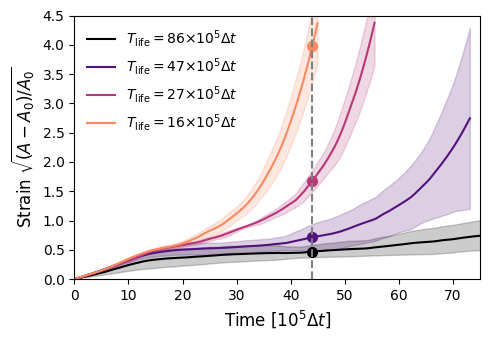

In [5]:
frame = TimeOG[5]-TimeOG[4]
print(frame)
frames = [200,200,200,200]
fig,ax=plt.subplots(figsize = (5,3.5))
#Strains_arr = np.array(Strains_all)
# Suppose Strains_all is a list of arrays of different lengths
lengths = [len(a) for a in Strains_all]
MaxLen = max(lengths)
N = len(Strains_all)

Strains_arr = np.full((N, MaxLen), np.nan)  # fill with NaN
Std_arr= np.full((N, MaxLen), np.nan)  # fill with NaN

for i, arr in enumerate(Strains_all):
    Strains_arr[i, :len(arr)] = arr
    
for i, arr in enumerate(Std_all):
    Std_arr[i, :len(arr)] = arr
times = np.multiply(np.arange(len(Strains_arr[0,:])),1)
print(np.shape(Strains_arr[:,0]))
lifetimes = np.round([8580699.284143684, 4706247.437784363, 2661235.159674766,1566475.77837646]).astype(int)
LifeTimeRound = np.round(np.divide(lifetimes,1e5))

for ii in range(len(Strains_arr[:,0])):
    t_plot = np.multiply(times,frames[ii])
    ax.plot(np.divide(t_plot,1e5),Strains_arr[ii,:],color = cmap(ii/4),label = r"$T_{\mathrm{life}}=$"+str(int(LifeTimeRound[ii]))+r"$\times10^5\Delta t$ ")
    ax.fill_between(np.divide(t_plot,1e5),np.add(Strains_arr[ii,:],-Std_arr[ii,:]),np.add(Strains_arr[ii,:],Std_arr[ii,:]),color = cmap(ii/4),alpha = 0.2)
    ArgMinTime = np.argmin(np.abs(t_plot/(1e5) - 44))
    argminInd = np.argmin(np.abs(Strains_arr[ii,:]-Strains_arr[ii,ArgMinTime]))
    print(argminInd)
    ax.plot(np.divide(t_plot[ArgMinTime],1e5),Strains_arr[ii,ArgMinTime],marker = 'o',color = cmap(ii/4),markersize = 7)

ax.plot([np.divide(t_plot[ArgMinTime],1e5),np.divide(t_plot[ArgMinTime],1e5)],[0,5],linestyle = '--',color = 'grey')
print(ArgMinTime)
ax.legend(frameon=False)
ax.set_ylabel(r"Strain $\sqrt{(A-A_{0})/A_{0}}$",fontsize = 12)
ax.set_xlabel(r'Time [$10^5\Delta t$]',fontsize = 12)
ax.set_xlim([0,75])
ax.set_ylim([0,4.5])
fig.tight_layout()
plotname = "Strain_Vs_4Lifetimes.pdf"
fig.savefig(plotsdir+plotname)
    

In [9]:
# ---- settings ----
outdir = Path(plotsdir) / "strain_4conditions_data"
outdir.mkdir(parents=True, exist_ok=True)

frames = [200, 200, 200, 200]  # you already set this
lifetimes = np.array([8580699.284143684, 4706247.437784363, 2661235.159674766, 1566475.77837646], dtype=float)
LifeTimeRound = np.round(lifetimes / 1e5).astype(int)

# sanity check
assert len(Strains_all) == 4, f"Expected 4 conditions, got {len(Strains_all)}"
assert len(Std_all) == 4, f"Expected 4 std arrays, got {len(Std_all)}"
assert len(frames) == 4

for ii in range(4):
    strain = np.asarray(Strains_all[ii], dtype=float)
    std    = np.asarray(Std_all[ii], dtype=float)

    n = min(len(strain), len(std))
    strain, std = strain[:n], std[:n]

    # time axis exactly as in your plot
    t = np.arange(n, dtype=float) * float(frames[ii])

    df = pandas.DataFrame({
        "Time": t,
        "AvStrain": strain,
        "StdStrain": std,
        # optional convenience column (matches your plotting x-axis)
        "Time_1e5": t / 1e5,
    })

    fname = outdir / f"Strain_condition{ii+1}_Tlife_{LifeTimeRound[ii]}x1e5dt.dat"
    df.to_csv(fname, sep=" ", index=False, float_format="%.8g")
    print("Wrote:", fname)


Wrote: /nfs/scistore26/saricgrp/bmeadowc/Scratch/Collagen/RiccyProject/Revision2/Assembly-AddDenseControl/Plotting/Plots/strain_4conditions_data/Strain_condition1_Tlife_86x1e5dt.dat
Wrote: /nfs/scistore26/saricgrp/bmeadowc/Scratch/Collagen/RiccyProject/Revision2/Assembly-AddDenseControl/Plotting/Plots/strain_4conditions_data/Strain_condition2_Tlife_47x1e5dt.dat
Wrote: /nfs/scistore26/saricgrp/bmeadowc/Scratch/Collagen/RiccyProject/Revision2/Assembly-AddDenseControl/Plotting/Plots/strain_4conditions_data/Strain_condition3_Tlife_27x1e5dt.dat
Wrote: /nfs/scistore26/saricgrp/bmeadowc/Scratch/Collagen/RiccyProject/Revision2/Assembly-AddDenseControl/Plotting/Plots/strain_4conditions_data/Strain_condition4_Tlife_16x1e5dt.dat
